In [15]:
from models.vqvae_single import VQVAE_Single
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torchvision

In [16]:
# checkpoint_path = 'ckpt/vqvae_single_epoch_32.pth'
# checkpoint_path = 'out_vqvae_fewer_stages1/ckpt/vqvae_single_epoch_40.pth'
checkpoint_path = 'out_vqvae_4_stages_2/ckpt/vqvae_single_epoch_180.pth'

In [17]:
from datasets.hqseg44k import HQSeg44KTrainDataset, HQSeg44KTestDataset
from datasets.coco_lvis import LvisDataset

In [18]:
# 创建数据加载器
# dataset = HQSeg44KTrainDataset(data_root='datasets/sam-hq')
dataset = HQSeg44KTrainDataset(data_root='data/sam-hq')

In [19]:
VOCAB_SIZE = 4096  # 码本大小
Z_CHANNELS = 32   # 潜在空间通道数
BASE_CHANNELS = 128  # 基础通道数
BETA = 0.25  # commitment loss权重
DEVICE = torch.device(f'cuda' if torch.cuda.is_available() else 'cpu')
# DEVICE = 'cpu'

# vqvae = VQVAE_Single(
#     vocab_size=VOCAB_SIZE,
#     z_channels=Z_CHANNELS,
#     ch=BASE_CHANNELS,
#     beta=BETA,
#     v_patch_nums=(1, 2, 4, 8, 12, 16, 20, 24, 28, 32),
#     test_mode=False,
#     ddconfig=dict(in_channels=1, ch_mult=(1, 1, 2, 4), num_res_blocks=2,   # 通道数乘数，用于构建网络层
#                 using_sa=True, using_mid_sa=True,)
# ).to(DEVICE)
from maskseg_build_everything import build_vqvae_single_fewer_stages, build_vqvae_single_4_stages
# vqvae = build_vqvae_single_fewer_stages(checkpoint_path)
vqvae = build_vqvae_single_4_stages(checkpoint_path)
vqvae.to(DEVICE)
vqvae.eval()

VQVAE_Single(
  (encoder): Encoder(
    (conv_in): Conv2d(1, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (down): ModuleList(
      (0-1): 2 x Module(
        (block): ModuleList(
          (0-1): 2 x ResnetBlock(
            (norm1): GroupNorm(32, 128, eps=1e-06, affine=True)
            (conv1): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            (norm2): GroupNorm(32, 128, eps=1e-06, affine=True)
            (dropout): Identity()
            (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            (nin_shortcut): Identity()
          )
        )
        (attn): ModuleList()
        (downsample): Downsample2x(
          (conv): Conv2d(128, 128, kernel_size=(3, 3), stride=(2, 2))
        )
      )
      (2): Module(
        (block): ModuleList(
          (0): ResnetBlock(
            (norm1): GroupNorm(32, 128, eps=1e-06, affine=True)
            (conv1): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padd

In [20]:
# vqvae.load_state_dict(torch.load('vae_ch160v4096z32.pth'))
vqvae.load_state_dict(torch.load(checkpoint_path, map_location=DEVICE)['model_state_dict'])

<All keys matched successfully>

In [21]:
# torch.save(vqvae.state_dict(), 'ckpt/vqvae_single.pth')

In [22]:
from utils.metrics import calc_iou

def visualize(item):
    image, mask, instance_info = item

    mask = torch.from_numpy(mask)
    print(mask.shape)
    mask = mask.permute(2, 0, 1)
    mask = mask * 2 - 1

    # result = vqvae.img_to_reconstructed_img(mask.to(DEVICE).unsqueeze(0))
    indices = vqvae.img_to_idxBl(mask.to(DEVICE).unsqueeze(0))
    result = vqvae.idxBl_to_img(indices, same_shape=True)
    for i in range(len(indices)):
        print(f'index {i}: {indices[i].shape}')
    # result_conv = [edge(item) for item in result]
    result = [mask / 2 + 0.5 for mask in result]
    chw = torchvision.utils.make_grid(torch.cat([torch.cat(result[1:], dim=0), mask.to(DEVICE).unsqueeze(0)], dim=0), nrow=3, 
    padding=1, pad_value=1.0)

    print(mask.shape, result[-1].shape)

    iou = calc_iou(result[-1], mask.to(DEVICE).unsqueeze(0))
    print(f'iou: {iou}')
    chw = chw.permute(1, 2, 0).mul_(255).cpu().numpy()
    chw = Image.fromarray(chw.astype(np.uint8))
    return chw

torch.Size([256, 256, 1])
index 0: torch.Size([1, 1])
index 1: torch.Size([1, 64])
index 2: torch.Size([1, 256])
index 3: torch.Size([1, 1024])
torch.Size([1, 256, 256]) torch.Size([1, 1, 256, 256])
iou: tensor([0.8908], device='cuda:0')


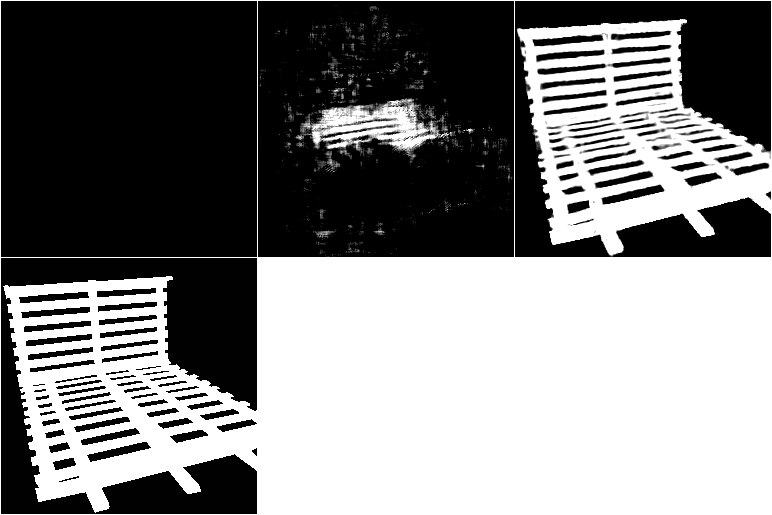

In [23]:
visualize(dataset[233])